# 04 — Croyances, connaissances et pratiques

Les notebooks 02 et 03 ont montré que *ce qu'on mange* se déduit mal de *qui l'on est*
socialement. Reste une autre piste : les **croyances et connaissances** nutritionnelles.
Les gens qui savent mangent-ils mieux ? Ce notebook confronte trois niveaux :

1. les **idées reçues** (questions Vrai/Faux `VF_*`) et le taux de bonnes réponses ;
2. un **score de connaissance** synthétique et ses déterminants ;
3. la confrontation **connaissance ↔ pratique** (Score Santé), et le rôle décisif du
   **passage à l'acte** (règle des « 5 fruits et légumes »).

## 1. Préparation et grille de correction

Pour chaque idée reçue, on fixe la **bonne réponse** (« Oui » = l'affirmation est vraie). On
ne garde que les réponses tranchées (« Oui » ou « Non »), en écartant la poignée de réponses
ambiguës « Oui, Non ».

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pingouin as pg
from scipy.stats import spearmanr
from IPython.display import display, Markdown

from utils.data_loader import load_data, clean_data

sns.set_theme(style="whitegrid", palette="muted")
df = clean_data(load_data())

BELIEFS = {
    "VF_saut":   ("Sauter un repas fait maigrir", "Non"),
    "VF_Eq_bon": ("Manger équilibré = pas bon", "Non"),
    "VF_Eq_Reg": ("Manger équilibré = être au régime", "Non"),
    "VF_Fec":    ("Les féculents font grossir", "Non"),
    "VF_Eq":     ("Manger équilibré coûte cher", "Non"),
    "VF_HO":     ("L'huile d'olive est meilleure", "Oui"),
    "VF_soir":   ("Manger léger le soir (recommandé)", "Oui"),
    "VF_medi":   ("Le régime méditerranéen est bénéfique", "Oui"),
    "VF_Su":     ("Le sucre roux est meilleur que le blanc", "Non"),
}
print(f"{len(BELIEFS)} idées reçues évaluées sur {df.shape[0]} répondants")

9 idées reçues évaluées sur 1681 répondants


## 2. Quelles idées reçues résistent ?

On calcule le taux de bonnes réponses pour chaque affirmation.

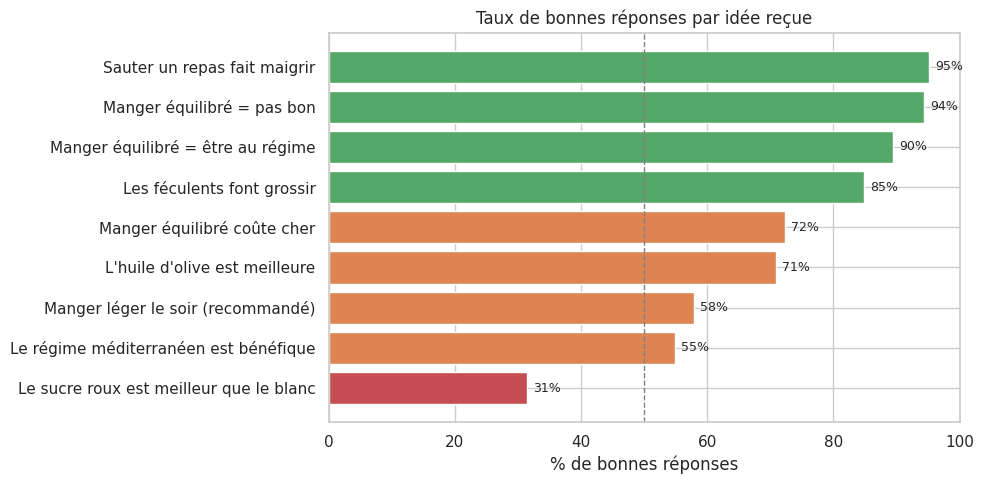

In [2]:
rows = []
for col, (lab, correct) in BELIEFS.items():
    clear = df[col].isin(["Oui", "Non"])
    rows.append({"Idée reçue": lab, "Bonne réponse": correct,
                 "% correct": round((df.loc[clear, col] == correct).mean() * 100, 1)})
res = pd.DataFrame(rows).sort_values("% correct")

colors = ["#C44E52" if p < 50 else "#DD8452" if p < 75 else "#55A868" for p in res["% correct"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(res["Idée reçue"], res["% correct"], color=colors)
ax.axvline(50, color="grey", ls="--", lw=1)
ax.set_xlabel("% de bonnes réponses"); ax.set_xlim(0, 100)
ax.set_title("Taux de bonnes réponses par idée reçue")
for y, p in enumerate(res["% correct"]):
    ax.text(p + 1, y, f"{p:.0f}%", va="center", fontsize=9)
fig.tight_layout()

Le contraste est saisissant. Les mythes les plus « scolaires » sont massivement déjoués :
*sauter un repas fait maigrir* (95 %), *équilibré = pas bon* (94 %), *= régime* (90 %). Mais
trois croyances résistent : l'idée que le **sucre roux serait meilleur que le blanc** n'est
rejetée que par **31 %** (deux personnes sur trois y croient), et seule une courte majorité
sait que le **régime méditerranéen** est bénéfique (55 %) ou que **manger léger le soir** est
recommandé (58 %). Les connaissances sont donc **inégales selon le sujet**, fortes sur les
messages de prévention grand public, faibles sur les détails nutritionnels.

## 3. Score de connaissance et niveau d'étude

On agrège les neuf réponses en un **score de connaissance** (0 à 9) et on teste s'il dépend
du diplôme — l'intuition étant que les plus diplômés en savent plus.

Score moyen : **6.44/9**. ANOVA de Welch selon le diplôme : F = 1.71, **p = 0.16** → pas de différence significative.

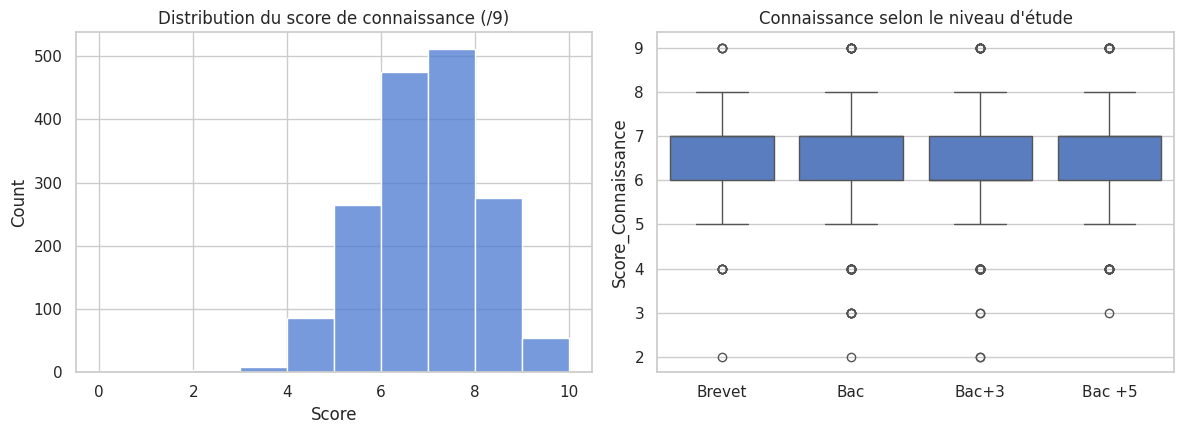

In [3]:
for col, (_, correct) in BELIEFS.items():
    df[col + "_ok"] = (df[col] == correct).astype(int)
df["Score_Connaissance"] = df[[c + "_ok" for c in BELIEFS]].sum(axis=1)

aov = pg.welch_anova(df.dropna(subset=["Etud"]), dv="Score_Connaissance", between="Etud").iloc[0]
moy = df.groupby("Etud", observed=True)["Score_Connaissance"].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Score_Connaissance"], bins=range(0, 11), ax=axes[0])
axes[0].set_title("Distribution du score de connaissance (/9)"); axes[0].set_xlabel("Score")
order = ["Brevet", "Bac", "Bac+3", "Bac +5"]
sns.boxplot(data=df, x="Etud", y="Score_Connaissance",
            order=[e for e in order if e in df["Etud"].unique()], ax=axes[1])
axes[1].set_title("Connaissance selon le niveau d'étude"); axes[1].set_xlabel("")
fig.tight_layout()
display(Markdown(f"Score moyen : **{df['Score_Connaissance'].mean():.2f}/9**. "
                 f"ANOVA de Welch selon le diplôme : F = {aov['F']:.2f}, **p = {aov['p-unc']:.2f}** "
                 f"→ pas de différence significative."))

Le score moyen est élevé (6,4/9) : la culture nutritionnelle de base est largement répandue.
Surtout, **le niveau d'étude ne fait aucune différence** (p = 0,16) : du Brevet au Bac+5, on
sait à peu près la même chose. C'est un résultat fort — la connaissance nutritionnelle ne se
distribue pas comme le capital scolaire.

## 4. Savoir, est-ce manger mieux ?

Le test central du notebook : le score de connaissance est-il lié au Score Santé (pratique
déclarée) ?

Corrélation de Spearman connaissance ↔ Score Santé : **ρ = 0.18** (p = 2.1e-13).

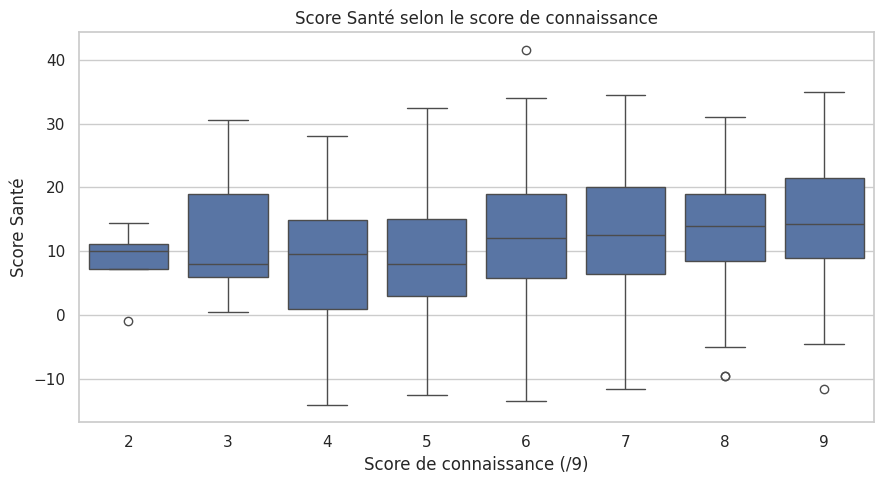

In [4]:
r = spearmanr(df["Score_Connaissance"], df["Score_Sante"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Score_Connaissance", y="Score_Sante", color="#4C72B0", ax=ax)
ax.set_title("Score Santé selon le score de connaissance")
ax.set_xlabel("Score de connaissance (/9)"); ax.set_ylabel("Score Santé")
fig.tight_layout()
display(Markdown(f"Corrélation de Spearman connaissance ↔ Score Santé : "
                 f"**ρ = {r.statistic:.2f}** (p = {r.pvalue:.1e})."))

La relation est **positive mais faible** (ρ = 0,18). Connaître les bons principes va de pair
avec une alimentation un peu meilleure, mais la connaissance **n'explique presque rien** des
écarts de pratique. Le savoir ne suffit pas : c'est tout l'écart entre *savoir* et *faire*.

## 5. Le vrai clivage : appliquer, pas seulement savoir

La règle des « 5 fruits et légumes par jour » permet de séparer ceux qui **connaissent** la
reco de ceux qui **l'appliquent**. On compare leur Score Santé.

« Applique / essaie » (moy. 14.1) vs « connaît mais n'applique pas » (moy. 6.0) : t-test **p = 2.3e-54**, **d de Cohen = 0.99** (effet large).

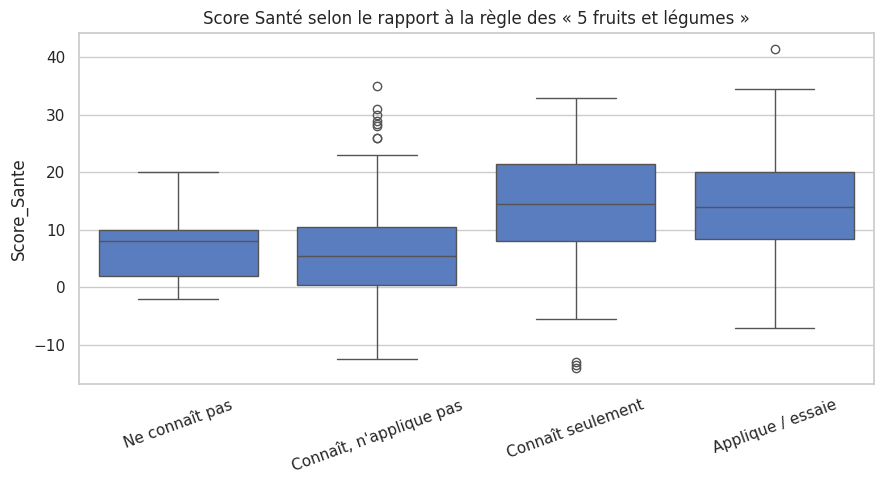

In [5]:
def app_group(s):
    if pd.isna(s): return np.nan
    if "Non je ne connais pas" in s: return "Ne connaît pas"
    if "J'applique" in s or "J'esaye" in s: return "Applique / essaie"
    if "Je n'applique pas" in s: return "Connaît, n'applique pas"
    if "Oui je connais" in s: return "Connaît seulement"
    return np.nan

df["app_5fj"] = df["5fj"].apply(app_group)
g = df.dropna(subset=["app_5fj"])
ordre = ["Ne connaît pas", "Connaît, n'applique pas", "Connaît seulement", "Applique / essaie"]
ordre = [o for o in ordre if o in g["app_5fj"].unique()]

a = g.loc[g["app_5fj"] == "Applique / essaie", "Score_Sante"]
b = g.loc[g["app_5fj"] == "Connaît, n'applique pas", "Score_Sante"]
tt = pg.ttest(a, b, correction=True).iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=g, x="app_5fj", y="Score_Sante", order=ordre, ax=ax)
ax.set_title("Score Santé selon le rapport à la règle des « 5 fruits et légumes »")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
display(Markdown(f"« Applique / essaie » (moy. {a.mean():.1f}) vs « connaît mais n'applique pas » "
                 f"(moy. {b.mean():.1f}) : t-test **p = {tt['p-val']:.1e}**, "
                 f"**d de Cohen = {tt['cohen-d']:.2f}** (effet large)."))

Voilà l'écart décisif. Entre ceux qui **essaient d'appliquer** la règle et ceux qui la
**connaissent sans l'appliquer**, la différence de Score Santé est **énorme** (14,1 vs 6,0 ;
*d* ≈ 1,0, l'un des plus gros effets de toute l'étude). Or presque tout le monde *connaît* la
règle : ce qui distingue les bons mangeurs n'est pas l'information, c'est la **mise en
pratique**.

## 6. Conscience du lien alimentation-santé

Dernier point de cadrage : les répondants font-ils le lien entre alimentation et santé ?

In [6]:
aware = pd.DataFrame({
    "Affirmation": ["L'alimentation peut causer des pathologies", "L'alimentation impacte la santé"],
    "% « Oui »": [round((df["A_patho"] == "Oui").mean() * 100, 1),
                  round((df["A_sante"] == "Oui").mean() * 100, 1)],
})
display(Markdown(aware.to_markdown(index=False)))

| Affirmation                                |   % « Oui » |
|:-------------------------------------------|------------:|
| L'alimentation peut causer des pathologies |        98.2 |
| L'alimentation impacte la santé            |        99.5 |

La conscience du lien alimentation-santé est **quasi universelle** (98-99 %). Le problème
n'est donc ni la sensibilisation générale, ni l'ignorance des grands principes : c'est, à
nouveau, le passage du savoir à l'acte.

## 7. Synthèse

**Ce que les gens savent.** La culture nutritionnelle de base est solide et, fait notable,
**indépendante du diplôme**. Les mythes « moraux » (sauter un repas, équilibré = privation)
sont déjoués ; restent quelques angles morts techniques, au premier rang desquels le **sucre
roux** (31 % de bonnes réponses) et la sous-estimation du **régime méditerranéen**.

**Le fossé savoir / faire.** La conscience que l'alimentation impacte la santé est
universelle (≈ 99 %), et le score de connaissance est élevé — mais il ne corrèle que
**faiblement** avec la pratique (ρ = 0,18). Savoir ne suffit pas.

**Le vrai levier : l'application.** La fracture nette ne sépare pas les savants des
ignorants, mais ceux qui **appliquent** des autres : essayer de suivre la règle des 5 fruits
et légumes va de pair avec un Score Santé deux fois supérieur (*d* ≈ 1,0). Pour une politique
de prévention, l'implication est claire : **informer ne suffit pas, il faut agir sur le
passage à l'acte** (motivation, accessibilité, habitudes) — ce que le notebook 05 explore via
les déterminants d'achat et l'influence marketing.